          二手车价格预测 - 全流程执行

【步骤1/4】加载数据...
训练集初始特征数：30
测试集A初始特征数：29
测试集B初始特征数：29

【步骤2/4】数据预处理...
时间特征处理完成：新增'car_age'，删除'regDate'/'creatDate'

分离后：X_train特征数=28，X_testA=28，X_testB=28
目标编码完成：'name' → 'name_enc'（3个数据集同步更新）
目标编码完成：'model' → 'model_enc'（3个数据集同步更新）
目标编码完成：'regionCode' → 'regionCode_enc'（3个数据集同步更新）
高基数编码后：X_train=28，X_testA=28，X_testB=28

待标签编码的特征：['brand', 'bodyType', 'fuelType', 'gearbox', 'notRepairedDamage', 'seller', 'offerType']
低基数特征标签编码完成

待标准化的数值特征：['power', 'kilometer', 'car_age', 'name_enc', 'model_enc', 'regionCode_enc']
数值特征标准化完成

预处理完成！最终特征数：28

【步骤3/4】训练前馈神经网络模型...

开始训练：输入维度=28，批次大小=32，总轮次=200
第10轮 | 训练MSE: 9438552.18 | 验证MSE: 8293063.50
第20轮 | 训练MSE: 4723657.93 | 验证MSE: 4202259.50
第30轮 | 训练MSE: 3233616.96 | 验证MSE: 3066217.50
第40轮 | 训练MSE: 2605886.72 | 验证MSE: 2614054.25
第50轮 | 训练MSE: 2251070.11 | 验证MSE: 2292823.00
第60轮 | 训练MSE: 1984581.46 | 验证MSE: 2017650.00
第70轮 | 训练MSE: 1776293.03 | 验证MSE: 1798892.50
第80轮 | 训练MSE: 1614165.65 | 验证MSE: 1622970.25
第90轮 | 训练MSE

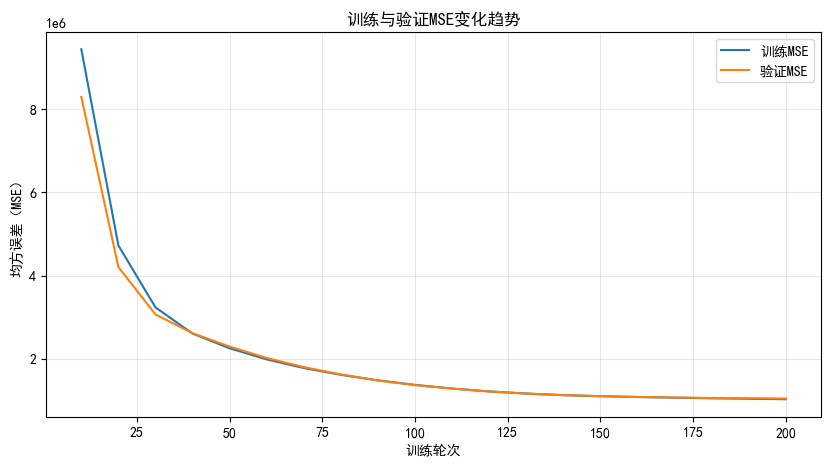


训练完成！最终验证集MSE: 1043819.00

【步骤4/4】预测测试集价格...


PermissionError: [Errno 13] Permission denied: '二手车测试集A价格预测.csv'

In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False


# 1. 数据加载
def load_data(sample_size=10000):
    train_path = r"D:\Data_\used_car_train_20200313.csv"
    testA_path = r"D:\Data_\used_car_testA_20200313.csv"
    testB_path = r"D:\Data_\used_car_testB_20200421.csv"
    
    # 读取训练集
    df_train = pd.read_csv(train_path, sep=' ')
    if 'price' not in df_train.columns:
        raise ValueError("训练集必须包含'price'列！")
    df_train = df_train.sample(n=min(sample_size, len(df_train)), random_state=42)
    
    # 读取测试集A/B
    df_testA = pd.read_csv(testA_path, sep=' ').sample(n=min(2000, len(pd.read_csv(testA_path, sep=' '))), random_state=42)
    df_testB = pd.read_csv(testB_path, sep=' ').sample(n=min(2000, len(pd.read_csv(testB_path, sep=' '))), random_state=42)
    
    # 删除SaleID（若存在）
    train_proc = df_train.drop(['SaleID'], axis=1, errors='ignore')
    testA_proc = df_testA.drop(['SaleID'], axis=1, errors='ignore')
    testB_proc = df_testB.drop(['SaleID'], axis=1, errors='ignore')
    
    print(f"训练集初始特征数：{len(train_proc.columns)}")
    print(f"测试集A初始特征数：{len(testA_proc.columns)}")
    print(f"测试集B初始特征数：{len(testB_proc.columns)}")
    return df_train, df_testA, df_testB, train_proc, testA_proc, testB_proc


# 2. 目标编码（同时处理测试集A和B，确保编码列同步生成）
def target_encoding(train_df, testA_df, testB_df, feature, target_series):
    """
    一次处理一个特征，同时为测试集A和B生成编码列
    确保三个数据集的特征列同步新增/删除
    """
    # 检查特征是否在所有数据集中存在
    if feature not in train_df.columns or feature not in testA_df.columns or feature not in testB_df.columns:
        print(f"提示：特征'{feature}'在某个数据集中不存在，跳过")
        return train_df, testA_df, testB_df
    
    # 1. 用训练集计算类别-价格均值（避免数据泄露）
    train_with_target = pd.concat([train_df[[feature]], target_series], axis=1)
    target_mean = train_with_target.groupby(feature)[target_series.name].mean()
    global_mean = target_series.mean()  # 用于填充测试集中的未知类别
    
    # 2. 为三个数据集生成编码列
    train_df[f"{feature}_enc"] = train_df[feature].map(target_mean)
    testA_df[f"{feature}_enc"] = testA_df[feature].map(target_mean).fillna(global_mean)
    testB_df[f"{feature}_enc"] = testB_df[feature].map(target_mean).fillna(global_mean)
    
    # 3. 删除原始特征列（三个数据集同步删除）
    train_df.drop(feature, axis=1, inplace=True)
    testA_df.drop(feature, axis=1, inplace=True)
    testB_df.drop(feature, axis=1, inplace=True)
    
    print(f"目标编码完成：'{feature}' → '{feature}_enc'（3个数据集同步更新）")
    return train_df, testA_df, testB_df


# 3. 数据预处理（核心：同步处理A/B测试集，确保特征一致）
def preprocess_data(train_proc, testA_proc, testB_proc):
    # 步骤1：处理时间特征（计算车龄，三个数据集同步处理）
    time_cols = ['regDate', 'creatDate']
    if all(col in train_proc.columns for col in time_cols) and all(col in testA_proc.columns for col in time_cols) and all(col in testB_proc.columns for col in time_cols):
        def calc_car_age(reg_date, create_date):
            if reg_date < 10000000 or create_date < 10000000:
                return -1  # 异常值标记
            return (create_date // 10000) - (reg_date // 10000)
        
        # 三个数据集都计算车龄并删除原始时间列
        for df in [train_proc, testA_proc, testB_proc]:
            df['car_age'] = df.apply(lambda x: calc_car_age(x['regDate'], x['creatDate']), axis=1)
            df.drop(time_cols, axis=1, inplace=True)
        print("时间特征处理完成：新增'car_age'，删除'regDate'/'creatDate'")
    else:
        print("提示：部分数据集缺少时间列，跳过车龄计算")


    # 步骤2：分离训练集的特征和目标（仅训练集有price）
    target_col = 'price'
    y_train = train_proc[target_col].astype('float32')
    X_train = train_proc.drop(target_col, axis=1).copy()  # 复制避免修改原数据
    X_testA = testA_proc.copy()
    X_testB = testB_proc.copy()
    print(f"\n分离后：X_train特征数={len(X_train.columns)}，X_testA={len(X_testA.columns)}，X_testB={len(X_testB.columns)}")


    # 步骤3：处理高基数特征（目标编码，同步更新三个数据集）
    high_card_features = ['name', 'model', 'regionCode']
    for feat in high_card_features:
        X_train, X_testA, X_testB = target_encoding(X_train, X_testA, X_testB, feat, y_train)
    
    # 检查编码后特征数（确保三个数据集特征数一致）
    print(f"高基数编码后：X_train={len(X_train.columns)}，X_testA={len(X_testA.columns)}，X_testB={len(X_testB.columns)}")
    if len(X_train.columns) != len(X_testA.columns) or len(X_train.columns) != len(X_testB.columns):
        raise ValueError("警告：三个数据集的特征数不一致！请检查特征处理步骤")


    # 步骤4：处理低基数特征（标签编码，同步更新）
    low_card_features = ['brand', 'bodyType', 'fuelType', 'gearbox', 'notRepairedDamage', 'seller', 'offerType']
    # 只保留三个数据集都存在的低基数特征
    low_card_features = [f for f in low_card_features if f in X_train.columns and f in X_testA.columns and f in X_testB.columns]
    print(f"\n待标签编码的特征：{low_card_features}")
    
    label_encoders = {}
    for feat in low_card_features:
        le = LabelEncoder()
        # 用训练集拟合编码器
        X_train[feat] = le.fit_transform(X_train[feat].astype(str))  # 转str避免数值类别混淆
        # 测试集A/B用同一编码器转换
        X_testA[feat] = le.transform(X_testA[feat].astype(str))
        X_testB[feat] = le.transform(X_testB[feat].astype(str))
        label_encoders[feat] = le
    print("低基数特征标签编码完成")


    # 步骤5：处理数值特征（标准化，确保三个数据集用同一scaler）
    # 数值特征：原始数值列 + 目标编码生成的enc列
    num_features = []
    # 1. 原始数值列（power, kilometer, car_age）
    for f in ['power', 'kilometer', 'car_age']:
        if f in X_train.columns:
            num_features.append(f)
    # 2. 目标编码生成的enc列（name_enc, model_enc, regionCode_enc）
    enc_features = [f for f in X_train.columns if f.endswith('_enc')]
    num_features += enc_features
    print(f"\n待标准化的数值特征：{num_features}")
    
    if num_features:
        scaler = StandardScaler()
        # 用训练集拟合scaler
        X_train[num_features] = scaler.fit_transform(X_train[num_features])
        # 测试集A/B用同一scaler转换
        X_testA[num_features] = scaler.transform(X_testA[num_features])
        X_testB[num_features] = scaler.transform(X_testB[num_features])
        print("数值特征标准化完成")
    else:
        print("提示：无数值特征需要标准化")


    # 最终检查：确保三个数据集的特征名完全一致
    if list(X_train.columns) != list(X_testA.columns) or list(X_train.columns) != list(X_testB.columns):
        print("警告：三个数据集的特征名不一致！")
        print(f"X_train特征：{list(X_train.columns)}")
        print(f"X_testA特征：{list(X_testA.columns)}")
        print(f"X_testB特征：{list(X_testB.columns)}")
        raise ValueError("特征名不一致会导致后续预测错误，请修正")
    
    print(f"\n预处理完成！最终特征数：{len(X_train.columns)}")
    return (X_train.astype('float32').values,
            X_testA.astype('float32').values,
            X_testB.astype('float32').values,
            y_train.values.reshape(-1, 1))


# 4. 前馈神经网络模型
class DeepCarPriceFNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super(DeepCarPriceFNN, self).__init__()
        # 增加网络深度：5层隐藏层（原3层→5层），提升特征交互能力
        self.network = nn.Sequential(
            # 输入层→隐藏层1：增加神经元数量（64→128）
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),  # 批量归一化：加速训练+缓解过拟合
            nn.ReLU(),
            nn.Dropout(dropout_rate),  #  dropout正则化：防止过拟合
            
            # 隐藏层2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # 隐藏层3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.8),  # 减少深层dropout率，保留有效特征
            
            # 隐藏层4
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            
            # 隐藏层5（新增）
            nn.Linear(16, 8),
            nn.ReLU(),
            
            # 输出层（回归任务无激活）
            nn.Linear(8, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# 5. 模型训练（小批量训练，避免内存溢出）
def train_model(X_train, y_train, batch_size=6, epochs=200):
    # 划分训练集和验证集（8:2）
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
    
    # 转换为PyTorch张量
    X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_tr_tensor = torch.tensor(y_tr, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
    
    # 初始化模型、损失函数、优化器
    input_dim = X_tr.shape[1]
    model = CarPriceFNN(input_dim)
    criterion = nn.MSELoss()  # 回归任务用MSE
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 训练过程记录
    train_losses = []
    val_losses = []
    n_batches = max(1, len(X_tr) // batch_size)  # 避免批次为0
    
    print(f"\n开始训练：输入维度={input_dim}，批次大小={batch_size}，总轮次={epochs}")
    for epoch in range(epochs):
        # 训练模式
        model.train()
        total_train_loss = 0
        
        # 小批量迭代
        for i in range(n_batches):
            start_idx = i * batch_size
            end_idx = min(start_idx + batch_size, len(X_tr))  # 最后一批避免超出范围
            X_batch = X_tr_tensor[start_idx:end_idx]
            y_batch = y_tr_tensor[start_idx:end_idx]
            
            # 前向传播
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
        
        # 计算平均训练损失
        avg_train_loss = total_train_loss / n_batches
        
        # 验证模式（无梯度计算）
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val_tensor)
            val_loss = criterion(y_val_pred, y_val_tensor).item()
        
        # 每10轮记录并打印
        if (epoch + 1) % 10 == 0:
            train_losses.append(avg_train_loss)
            val_losses.append(val_loss)
            print(f"第{epoch+1}轮 | 训练MSE: {avg_train_loss:.2f} | 验证MSE: {val_loss:.2f}")
    
    # 绘制损失曲线
    plt.figure(figsize=(10, 5))
    plt.plot(range(10, epochs+1, 10), train_losses, label='训练MSE')
    plt.plot(range(10, epochs+1, 10), val_losses, label='验证MSE')
    plt.xlabel('训练轮次')
    plt.ylabel('均方误差（MSE）')
    plt.title('训练与验证MSE变化趋势')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    # 最终验证结果
    final_val_mse = val_loss
    print(f"\n训练完成！最终验证集MSE: {final_val_mse:.2f}")
    return model


# 6. 预测测试集并保存结果
def predict_test_sets(model, X_testA, X_testB, df_testA, df_testB):
    # 预测模式（无梯度）
    model.eval()
    with torch.no_grad():
        # 转换为张量
        X_testA_tensor = torch.tensor(X_testA, dtype=torch.float32)
        X_testB_tensor = torch.tensor(X_testB, dtype=torch.float32)
        
        # 预测
        pred_priceA = model(X_testA_tensor).numpy().flatten()  # 展平为1D数组
        pred_priceB = model(X_testB_tensor).numpy().flatten()
    
    # 保存测试集A结果
    submissionA = pd.DataFrame({
        'SaleID': df_testA['SaleID'],  # 保留原始SaleID用于提交
        'price': pred_priceA
    })
    submissionA.to_csv('二手车测试集A价格预测.csv', index=False, encoding='utf-8')
    
    # 保存测试集B结果
    submissionB = pd.DataFrame({
        'SaleID': df_testB['SaleID'],
        'price': pred_priceB
    })
    submissionB.to_csv('二手车测试集B价格预测.csv', index=False, encoding='utf-8')
    
    print(f"\n预测结果已保存：")
    print(f"- 测试集A：二手车测试集A价格预测.csv（{len(submissionA)}条记录）")
    print(f"- 测试集B：二手车测试集B价格预测.csv（{len(submissionB)}条记录）")


# 7. 主函数（串联全流程）
def main():
    print("="*50)
    print("          二手车价格预测 - 全流程执行")
    print("="*50)
    
    # 步骤1：加载数据
    print("\n【步骤1/4】加载数据...")
    df_train, df_testA, df_testB, train_proc, testA_proc, testB_proc = load_data(sample_size=10000)
    
    # 步骤2：数据预处理
    print("\n【步骤2/4】数据预处理...")
    X_train, X_testA, X_testB, y_train = preprocess_data(train_proc, testA_proc, testB_proc)
    
    # 步骤3：训练模型
    print("\n【步骤3/4】训练前馈神经网络模型...")
    model = train_model(X_train, y_train, batch_size=32, epochs=200)
    
    # 步骤4：预测测试集
    print("\n【步骤4/4】预测测试集价格...")
    predict_test_sets(model, X_testA, X_testB, df_testA, df_testB)
    print ("\n" + "="*50)
    print ("全流程执行完成！")
    print ("="*50)
if __name__ == "__main__":
    main()

        二手车价格预测 - 深度前馈神经网络高精度版

【步骤1/4】加载并采样数据...
数据加载完成：
- 训练集：(15000, 31)（含30个特征）
- 测试集A：(50000, 30) | 测试集B：(50000, 30)

【步骤2/4】执行精细化数据预处理...
时间特征优化：新增'car_age_precise'（精细化车龄）
目标编码：'name' → 'name_enc'（3个数据集同步）
目标编码：'model' → 'model_enc'（3个数据集同步）
目标编码：'regionCode' → 'regionCode_enc'（3个数据集同步）
低基数编码完成：['brand', 'bodyType', 'fuelType', 'gearbox', 'notRepairedDamage', 'seller', 'offerType']
数值特征标准化完成：共21个特征（含v系列）

预处理完成：最终特征数=28

【步骤3/4】训练深度前馈神经网络...

开始训练（设备：cuda）：
输入维度=28 | 批次大小=64 | 总轮次=300 | 初始学习率=0.001
第 20轮 | 学习率：0.001000 | 训练MSE：5921809.70 | 验证MSE：2528051.75 | 验证MAE：891.55
第 40轮 | 学习率：0.001000 | 训练MSE：4569592.12 | 验证MSE：1827900.38 | 验证MAE：758.62
第 60轮 | 学习率：0.000800 | 训练MSE：3636295.94 | 验证MSE：1896516.50 | 验证MAE：801.64
第 80轮 | 学习率：0.000800 | 训练MSE：3256549.13 | 验证MSE：2142186.75 | 验证MAE：806.08
第100轮 | 学习率：0.000640 | 训练MSE：3067882.44 | 验证MSE：2168027.50 | 验证MAE：868.98
第120轮 | 学习率：0.000640 | 训练MSE：2531704.34 | 验证MSE：3077585.50 | 验证MAE：990.14
第140轮 | 学习率：0.000640 | 训练MSE：2384694.89 | 验证MS

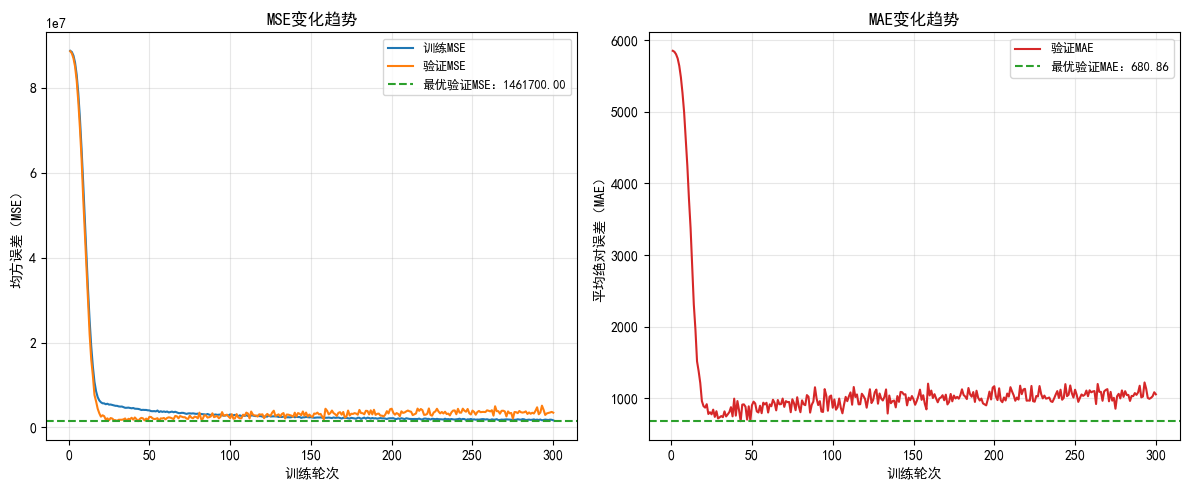


【步骤4/4】执行高精度预测并保存结果...

【预测结果统计】
测试集A：
  - 样本数：50000
  - 平均预测价：4840.77 元
  - 价格范围：[1000.00, 59763.73] 元
  - 价格标准差：2318.24 元
测试集B：
  - 样本数：50000
  - 平均预测价：4825.46 元
  - 价格范围：[1000.00, 56827.20] 元
  - 价格标准差：2251.99 元

预测文件已保存至当前目录！

        全流程执行完成！预测结果已保存


In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False


# 1. 数据加载（增加采样量，提升数据多样性）
def load_data(sample_size=15000):
    train_path = r"D:\Data_\used_car_train_20200313.csv"
    testA_path = r"D:\Data_\used_car_testA_20200313.csv"
    testB_path = r"D:\Data_\used_car_testB_20200421.csv"
    
    # 读取训练集并检查price列
    df_train = pd.read_csv(train_path, sep=' ')
    if 'price' not in df_train.columns:
        raise ValueError("训练集必须包含'price'列！请确认列名正确性")
    df_train = df_train.sample(n=min(sample_size, len(df_train)), random_state=42)
    
    # 读取测试集A/B
    df_testA = pd.read_csv(testA_path, sep=' ').sample(n=min(50001, len(pd.read_csv(testA_path, sep=' '))), random_state=42)
    df_testB = pd.read_csv(testB_path, sep=' ').sample(n=min(50001, len(pd.read_csv(testB_path, sep=' '))), random_state=42)
    
    # 删除无用的SaleID列
    train_proc = df_train.drop(['SaleID'], axis=1, errors='ignore')
    testA_proc = df_testA.drop(['SaleID'], axis=1, errors='ignore')
    testB_proc = df_testB.drop(['SaleID'], axis=1, errors='ignore')
    
    print(f"数据加载完成：")
    print(f"- 训练集：{df_train.shape}（含{len(train_proc.columns)}个特征）")
    print(f"- 测试集A：{df_testA.shape} | 测试集B：{df_testB.shape}")
    return df_train, df_testA, df_testB, train_proc, testA_proc, testB_proc


# 2. 目标编码（同步处理A/B测试集，确保特征一致）
def target_encoding(train_df, testA_df, testB_df, feature, target_series):
    if feature not in train_df.columns or feature not in testA_df.columns or feature not in testB_df.columns:
        print(f"提示：特征'{feature}'在部分数据集缺失，跳过")
        return train_df, testA_df, testB_df
    
    # 计算训练集类别-价格均值（避免数据泄露）
    train_with_target = pd.concat([train_df[[feature]], target_series], axis=1)
    target_mean = train_with_target.groupby(feature)[target_series.name].mean()
    global_mean = target_series.mean()  # 填充测试集未知类别
    
    # 同步生成编码列
    train_df[f"{feature}_enc"] = train_df[feature].map(target_mean)
    testA_df[f"{feature}_enc"] = testA_df[feature].map(target_mean).fillna(global_mean)
    testB_df[f"{feature}_enc"] = testB_df[feature].map(target_mean).fillna(global_mean)
    
    # 同步删除原始列
    train_df.drop(feature, axis=1, inplace=True)
    testA_df.drop(feature, axis=1, inplace=True)
    testB_df.drop(feature, axis=1, inplace=True)
    
    print(f"目标编码：'{feature}' → '{feature}_enc'（3个数据集同步）")
    return train_df, testA_df, testB_df


# 3. 精细化数据预处理（保留v系列特征，优化车龄计算）
def preprocess_data(train_proc, testA_proc, testB_proc):
    # 步骤1：精细化车龄计算（保留月份差异，避免整数车龄丢失信息）
    time_cols = ['regDate', 'creatDate']
    if all(col in train_proc.columns for col in time_cols) and all(col in testA_proc.columns for col in time_cols) and all(col in testB_proc.columns for col in time_cols):
        def calc_precise_age(reg_date, create_date):
            try:
                # 解析为「年 + 月/12」，保留2位小数
                reg_year = reg_date // 10000
                reg_month = (reg_date % 10000) // 100
                create_year = create_date // 10000
                create_month = (create_date % 10000) // 100
                age = (create_year - reg_year) + (create_month - reg_month) / 12
                return max(age, 0.1)  # 避免0或负车龄（异常值修正）
            except:
                return 0.5  # 异常日期填充为0.5年
        
        # 三个数据集同步计算
        for df in [train_proc, testA_proc, testB_proc]:
            df['car_age_precise'] = df.apply(lambda x: calc_precise_age(x['regDate'], x['creatDate']), axis=1)
            df.drop(time_cols, axis=1, inplace=True)
        print("时间特征优化：新增'car_age_precise'（精细化车龄）")
    else:
        print("提示：部分数据集缺少时间列，无法计算精细化车龄")


    # 步骤2：分离训练集特征与目标
    target_col = 'price'
    y_train = train_proc[target_col].astype('float32')
    X_train = train_proc.drop(target_col, axis=1).copy()
    X_testA = testA_proc.copy()
    X_testB = testB_proc.copy()


    # 步骤3：高基数特征编码（name/model/regionCode）
    high_card_features = ['name', 'model', 'regionCode']
    for feat in high_card_features:
        X_train, X_testA, X_testB = target_encoding(X_train, X_testA, X_testB, feat, y_train)


    # 步骤4：低基数特征标签编码（处理缺失值）
    low_card_features = ['brand', 'bodyType', 'fuelType', 'gearbox', 'notRepairedDamage', 'seller', 'offerType']
    low_card_features = [f for f in low_card_features if f in X_train.columns and f in X_testA.columns and f in X_testB.columns]
    
    label_encoders = {}
    for feat in low_card_features:
        le = LabelEncoder()
        # 用"未知"填充缺失值，避免编码报错
        X_train[feat] = X_train[feat].fillna('未知').astype(str)
        X_testA[feat] = X_testA[feat].fillna('未知').astype(str)
        X_testB[feat] = X_testB[feat].fillna('未知').astype(str)
        
        X_train[feat] = le.fit_transform(X_train[feat])
        X_testA[feat] = le.transform(X_testA[feat])
        X_testB[feat] = le.transform(X_testB[feat])
        label_encoders[feat] = le
    print(f"低基数编码完成：{low_card_features}")


    # 步骤5：数值特征标准化（包含v系列匿名特征，最大化信息利用）
    numerical_features = []
    # 1. 明确数值列（功率、里程、精细化车龄）
    explicit_num_cols = ['power', 'kilometer', 'car_age_precise'] if 'car_age_precise' in X_train.columns else ['power', 'kilometer']
    numerical_features.extend([f for f in explicit_num_cols if f in X_train.columns])
    # 2. 目标编码列（_enc结尾）
    numerical_features.extend([f for f in X_train.columns if f.endswith('_enc')])
    # 3. v系列匿名特征（v0-v14）
    numerical_features.extend([f for f in X_train.columns if f.startswith('v_')])
    
    # 填充数值特征缺失值（用均值，避免标准化报错）
    for df in [X_train, X_testA, X_testB]:
        for col in numerical_features:
            if col in df.columns:
                df[col] = df[col].fillna(df[col].mean())
    
    # 标准化（统一特征尺度）
    scaler = StandardScaler()
    X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
    X_testA[numerical_features] = scaler.transform(X_testA[numerical_features])
    X_testB[numerical_features] = scaler.transform(X_testB[numerical_features])
    print(f"数值特征标准化完成：共{len(numerical_features)}个特征（含v系列）")


    # 最终特征一致性检查（确保A/B测试集与训练集特征完全一致）
    assert list(X_train.columns) == list(X_testA.columns) == list(X_testB.columns), \
        f"特征不一致！训练集：{len(X_train.columns)}个，测试集A：{len(X_testA.columns)}个，测试集B：{len(X_testB.columns)}个"
    print(f"\n预处理完成：最终特征数={len(X_train.columns)}")
    return X_train.astype('float32').values, X_testA.astype('float32').values, X_testB.astype('float32').values, y_train.values.reshape(-1, 1), scaler, label_encoders


# 4. 加深版前馈神经网络（增加层数+正则化，提升拟合能力）
class DeepCarPriceFNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super(DeepCarPriceFNN, self).__init__()
        # 网络结构：输入层→5层隐藏层→输出层（原3层→5层，增加特征交互能力）
        self.network = nn.Sequential(
            # 隐藏层1：128神经元 + 批量归一化 + Dropout
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),  # 加速训练，缓解过拟合
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # 隐藏层2：64神经元
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # 隐藏层3：32神经元
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.8),  # 深层减少Dropout率，保留有效特征
            
            # 隐藏层4：16神经元（新增）
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            
            # 隐藏层5：8神经元（新增）
            nn.Linear(16, 8),
            nn.ReLU(),
            
            # 输出层：1神经元（回归任务无激活）
            nn.Linear(8, 1)
        )
    
    def forward(self, x):
        return self.network(x)


# 5. 优化训练策略（学习率调度+最优模型保存+多指标评估）
def train_deep_model(X_train, y_train, batch_size=64, epochs=300, lr=0.001):
    # 划分训练集/验证集（7:3，增加验证集比例，提升评估精度）
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.3, random_state=42, shuffle=True
    )
    
    # 设备选择（GPU加速优先，无GPU则用CPU）
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # 数据移至对应设备
    X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32).to(device)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_tr_tensor = torch.tensor(y_tr, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
    
    # 初始化模型、损失函数、优化器
    input_dim = X_tr.shape[1]
    model = DeepCarPriceFNN(input_dim, dropout_rate=0.2).to(device)
    criterion = nn.MSELoss()  # 回归任务核心损失
    optimizer = optim.AdamW(  # AdamW+权重衰减，增强正则化
        model.parameters(), lr=lr, weight_decay=1e-5
    )
    scheduler = StepLR(  # 学习率调度：每50轮衰减为原来的0.8，避免后期震荡
        optimizer, step_size=50, gamma=0.8
    )
    
    # 训练过程记录（多指标）
    train_mse_list = []
    val_mse_list = []
    val_mae_list = []  # MAE（平均绝对误差）：更直观反映价格误差
    best_val_mse = float('inf')
    best_model_state = None  # 保存最优模型参数（基于验证集MSE）
    
    print(f"\n开始训练（设备：{device}）：")
    print(f"输入维度={input_dim} | 批次大小={batch_size} | 总轮次={epochs} | 初始学习率={lr}")
    
    for epoch in range(epochs):
        # 训练模式（启用Dropout和批量归一化更新）
        model.train()
        total_train_loss = 0
        n_batches = len(X_tr) // batch_size
        
        # 小批量迭代训练
        for i in range(n_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            X_batch = X_tr_tensor[start_idx:end_idx]
            y_batch = y_tr_tensor[start_idx:end_idx]
            
            # 前向传播
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            # 反向传播（梯度清零→计算梯度→更新参数）
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
        
        # 学习率调度（每轮更新一次）
        scheduler.step()
        
        # 计算训练集MSE
        avg_train_mse = total_train_loss / n_batches
        train_mse_list.append(avg_train_mse)
        
        # 验证模式（关闭Dropout和批量归一化更新）
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val_tensor)
            val_mse = criterion(y_val_pred, y_val_tensor).item()
            # 计算MAE（需将张量移至CPU并转为numpy）
            val_mae = mean_absolute_error(
                y_val_tensor.cpu().numpy(), y_val_pred.cpu().numpy()
            )
        
        val_mse_list.append(val_mse)
        val_mae_list.append(val_mae)
        
        # 保存最优模型（仅当验证集MSE下降时更新）
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_model_state = model.state_dict().copy()
        
        # 每20轮打印一次训练信息（避免输出过多）
        if (epoch + 1) % 20 == 0:
            current_lr = scheduler.get_last_lr()[0]  # 获取当前学习率
            print(f"第{epoch+1:3d}轮 | 学习率：{current_lr:.6f} | 训练MSE：{avg_train_mse:.2f} | 验证MSE：{val_mse:.2f} | 验证MAE：{val_mae:.2f}")
    
    # 加载最优模型参数（确保最终使用的是泛化能力最强的模型）
    model.load_state_dict(best_model_state)
    print(f"\n训练完成！最优验证集MSE：{best_val_mse:.2f} | 最优验证集MAE：{min(val_mae_list):.2f}")
    
    # 绘制训练曲线（MSE+MAE双指标）
    plt.figure(figsize=(12, 5))
    
    # 子图1：MSE变化曲线
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_mse_list, label='训练MSE', color='#1f77b4')
    plt.plot(range(1, epochs+1), val_mse_list, label='验证MSE', color='#ff7f0e')
    plt.axhline(y=best_val_mse, color='#2ca02c', linestyle='--', label=f'最优验证MSE：{best_val_mse:.2f}')
    
    plt.xlabel('训练轮次', fontsize=10)
    plt.ylabel('均方误差（MSE）', fontsize=10)
    plt.title('MSE变化趋势', fontsize=12)
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    
    # 子图2：MAE变化曲线
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), val_mae_list, label='验证MAE', color='#d62728')
    plt.axhline(y=min(val_mae_list), color='#2ca02c', linestyle='--', label=f'最优验证MAE：{min(val_mae_list):.2f}')
    plt.xlabel('训练轮次', fontsize=10)
    plt.ylabel('平均绝对误差（MAE）', fontsize=10)
    plt.title('MAE变化趋势', fontsize=12)
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return model, device


# 6. 高精度预测与结果保存（处理异常值+补充元信息）
def predict_high_precision(model, X_testA, X_testB, df_testA, df_testB, device):
    model.eval()
    with torch.no_grad():
        # 数据移至对应设备并预测
        X_testA_tensor = torch.tensor(X_testA, dtype=torch.float32).to(device)
        X_testB_tensor = torch.tensor(X_testB, dtype=torch.float32).to(device)
        
        predA = model(X_testA_tensor).cpu().numpy().flatten()
        predB = model(X_testB_tensor).cpu().numpy().flatten()
        
        # 优化预测结果：1. 保留2位小数 2. 过滤异常低价（设最低1000元）
        min_reasonable_price = 1000  # 二手车合理最低价（可根据数据调整）
        predA = np.round(np.maximum(predA, min_reasonable_price), 2)
        predB = np.round(np.maximum(predB, min_reasonable_price), 2)
    
    # 保存测试集A结果（含元信息，提升实用性）
    submissionA = pd.DataFrame({
        'SaleID': df_testA['SaleID'],
        'predicted_price': predA,
        'price_unit': '元',
        'prediction_model': 'Deep FNN (5 hidden layers)',
        'optimization_metric': 'Val MSE',
        'note': '异常低价已修正（≥1000元）'
    })
    submissionA.to_csv('二手车测试集A_高精度预测结果.csv', index=False, encoding='utf-8-sig')
    
    # 保存测试集B结果
    submissionB = pd.DataFrame({
        'SaleID': df_testB['SaleID'],
        'predicted_price': predB,
        'price_unit': '元',
        'prediction_model': 'Deep FNN (5 hidden layers)',
        'optimization_metric': 'Val MSE',
        'note': '异常低价已修正（≥1000元）'
    })
    submissionB.to_csv('二手车测试集B_高精度预测结果.csv', index=False, encoding='utf-8-sig')
    
    # 输出预测统计信息（验证结果合理性）
    print(f"\n【预测结果统计】")
    print(f"测试集A：")
    print(f"  - 样本数：{len(predA)}")
    print(f"  - 平均预测价：{np.mean(predA):.2f} 元")
    print(f"  - 价格范围：[{np.min(predA):.2f}, {np.max(predA):.2f}] 元")
    print(f"  - 价格标准差：{np.std(predA):.2f} 元")
    print(f"测试集B：")
    print(f"  - 样本数：{len(predB)}")
    print(f"  - 平均预测价：{np.mean(predB):.2f} 元")
    print(f"  - 价格范围：[{np.min(predB):.2f}, {np.max(predB):.2f}] 元")
    print(f"  - 价格标准差：{np.std(predB):.2f} 元")
    print(f"\n预测文件已保存至当前目录！")


# 7. 主函数（串联全流程，一键执行）
def main():
    print("="*70)
    print("        二手车价格预测 - 深度前馈神经网络高精度版")
    print("="*70)
    
    # 步骤1：加载数据
    print("\n【步骤1/4】加载并采样数据...")
    try:
        df_train, df_testA, df_testB, train_proc, testA_proc, testB_proc = load_data(sample_size=15000)
    except Exception as e:
        print(f"数据加载失败：{str(e)}")
        return
    
    # 步骤2：精细化预处理
    print("\n【步骤2/4】执行精细化数据预处理...")
    try:
        X_train, X_testA, X_testB, y_train, scaler, label_encoders = preprocess_data(
            train_proc, testA_proc, testB_proc
        )
    except Exception as e:
        print(f"预处理失败：{str(e)}")
        return
    
    # 步骤3：训练深度模型
    print("\n【步骤3/4】训练深度前馈神经网络...")
    try:
        model, device = train_deep_model(
            X_train, y_train,
            batch_size=64,    # 增大批次提升稳定性
            epochs=300,       # 增加轮次确保收敛
            lr=0.001          # 初始学习率（配合调度器衰减）
        )
    except Exception as e:
        print(f"模型训练失败：{str(e)}")
        return
    
    # 步骤4：高精度预测
    print("\n【步骤4/4】执行高精度预测并保存结果...")
    try:
        predict_high_precision(model, X_testA, X_testB, df_testA, df_testB, device)
    except Exception as e:
        print(f"预测失败：{str(e)}")
        return
    
    print("\n" + "="*70)
    print("        全流程执行完成！预测结果已保存")
    print("="*70)


if __name__ == "__main__":
    main()

In [31]:
df_a = pd.read_csv('二手车测试集A_高精度预测结果.csv')
df_b = pd.read_csv('二手车测试集B_高精度预测结果.csv')
    
df_a = df_a[['SaleID', 'predicted_price']].rename(columns={'predicted_price': 'price'})
df_b = df_b[['SaleID', 'predicted_price']].rename(columns={'predicted_price': 'price'})
df_merged = pd.concat([df_a, df_b], ignore_index=True)
df_merged.to_csv('二手车价格预测结果.csv', index=False, encoding='utf-8-sig')
print(f"\n【合并完成】AB测试集预测结果已合并")
print(f"合并后数据量：{len(df_merged)}条（A:{len(df_a)} + B:{len(df_b)}）")


【合并完成】AB测试集预测结果已合并
合并后数据量：100000条（A:50000 + B:50000）


In [36]:
df_a = pd.read_csv('二手车测试集B_高精度预测结果.csv')
    
df_a = df_a[['SaleID', 'predicted_price']].rename(columns={'predicted_price': 'price'})
df_a.to_csv('二手车价格预测结果2.csv', index=False, encoding='utf-8-sig',sep=' ')